# EDA dữ liệu VisDrone cho bài toán Object Detection

Notebook này kiểm tra cấu trúc dữ liệu, tính toàn vẹn ảnh/nhãn, phân phối lớp, kích thước ảnh, mật độ đối tượng, hình học bounding box, mức che khuất/cắt cụt và trực quan hóa mẫu. Phần cuối chuyển các phát hiện thành quyết định preprocessing cụ thể.

**Định dạng nhãn gốc:** `x, y, width, height, score, category, truncation, occlusion`. Category `1..10` là 10 lớp huấn luyện; category `0`, `11` và dòng có `score=0` không được đưa vào nhãn YOLO.

In [1]:
from pathlib import Path
import sys

def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'src').is_dir() and (candidate / 'data').is_dir():
            return candidate
    raise FileNotFoundError('Không tìm thấy project root chứa src/ và data/.')

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_ROOT = PROJECT_ROOT / 'data'
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
print('Project root:', PROJECT_ROOT)
print('Data root   :', DATA_ROOT)

Project root: D:\Hoctap\Nam 3\hk3\statiscal learning\object_dectection
Data root   : D:\Hoctap\Nam 3\hk3\statiscal learning\object_dectection\data


In [2]:
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image, ImageDraw

from visdrone_data import CLASS_NAMES, discover_splits, read_annotation_file, scan_dataset

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 30)
RANDOM_SEED = 42
SPLITS = ('train', 'val', 'test-dev')
random.seed(RANDOM_SEED)

## 1. Khám phá cấu trúc và quét dữ liệu

Hàm quét tự xử lý trường hợp archive tạo hai thư mục trùng tên, ví dụ `VisDrone2019-DET-train/VisDrone2019-DET-train`. Không cần di chuyển dữ liệu gốc.

In [3]:
split_paths = discover_splits(DATA_ROOT)
pd.DataFrame([{'split': split_name, 'path': path} for split_name, path in split_paths.items()])

,split,path
0,train,D:\Hoctap\Nam 3\hk3\statiscal learning\object_...
1,val,D:\Hoctap\Nam 3\hk3\statiscal learning\object_...
2,test-dev,D:\Hoctap\Nam 3\hk3\statiscal learning\object_...
3,test-challenge,D:\Hoctap\Nam 3\hk3\statiscal learning\object_...


In [4]:
# Quét toàn bộ metadata ảnh và annotation; có thể mất khoảng 1-2 phút.
images_df, boxes_df, integrity_df = scan_dataset(DATA_ROOT, SPLITS)
print(f'{len(images_df):,} ảnh; {len(boxes_df):,} annotation gốc')
integrity_df

8,629 ảnh; 471,266 annotation gốc


,split,split_path,images,annotations,missing_annotations,missing_images,unreadable_images,malformed_rows
0,train,D:\Hoctap\Nam 3\hk3\statiscal learning\object_...,6471,6471,0,0,0,0
1,val,D:\Hoctap\Nam 3\hk3\statiscal learning\object_...,548,548,0,0,0,0
2,test-dev,D:\Hoctap\Nam 3\hk3\statiscal learning\object_...,1610,1610,0,0,0,0


## 2. Tính toàn vẹn dữ liệu

Các cột `missing_*`, `unreadable_images` và `malformed_rows` phải bằng 0 trước khi train. Ảnh test-challenge không có annotation theo thiết kế nên không nằm trong lần quét huấn luyện này.

In [5]:
quality_columns = ['missing_annotations', 'missing_images', 'unreadable_images', 'malformed_rows']
integrity_df[['split', 'images', 'annotations', *quality_columns]]

,split,images,annotations,missing_annotations,missing_images,unreadable_images,malformed_rows
0,train,6471,6471,0,0,0,0
1,val,548,548,0,0,0,0
2,test-dev,1610,1610,0,0,0,0


In [6]:
status_table = (boxes_df.groupby(['split', 'status']).size()
                .unstack(fill_value=0)
                .assign(total=lambda frame: frame.sum(axis=1)))
status_table.loc['TOTAL'] = status_table.sum()
status_table

status,ignored_score,keep,non_positive_boxes,total
split,,,,
test-dev,2445,75102,0,77547
train,10345,343204,1,353550
val,1410,38759,0,40169
TOTAL,14200,457065,1,471266


## 3. Kích thước và tỉ lệ ảnh

YOLO tự letterbox ảnh về `imgsz`; không resize đè lên ảnh gốc. Nên chọn `imgsz` đủ lớn vì VisDrone có nhiều vật thể rất nhỏ.

width                                                          \
           count     mean     std    min     25%     50%     75%     max   
split                                                                      
test-dev  1610.0  1442.48  187.87  960.0  1400.0  1400.0  1400.0  1920.0   
train     6471.0  1519.89  269.52  480.0  1400.0  1400.0  1916.0  2000.0   
val        548.0  1291.09  203.79  960.0  1360.0  1360.0  1360.0  1920.0   

          height                                                 ...  \
           count     mean     std    min    25%     50%     75%  ...   
split                                                            ...   
test-dev  1610.0   856.38  136.89  540.0  788.0   788.0  1050.0  ...   
train     6471.0  1002.40  235.06  360.0  788.0  1050.0  1078.0  ...   
val        548.0   726.24  114.63  540.0  765.0   765.0   765.0  ...   

         aspect_ratio                                     file_size_kb  \
                 mean   std   min   25%   50%   75%   max        count   
split                                                                    
test-dev         1.70  0.17  1.33  1.78  1.78  1.78  1.78       1610.0   
train            1.55  0.22  1.33  1.33  1.33  1.78  1.78       6471.0   
val              1.78  0.00  1.78  1.78  1.78  1.78  1.78        548.0   

                                                                 
            mean     std    min     25%     50%     75%     max  
split                                                            
test-dev  188.65   86.68  43.70  125.93  181.86  215.24  496.87  
train     233.60  125.55  19.94  145.63  202.90  287.41  824.72  
val       144.72   58.50  33.01  103.71  139.38  167.34  468.00  

[3 rows x 32 columns]

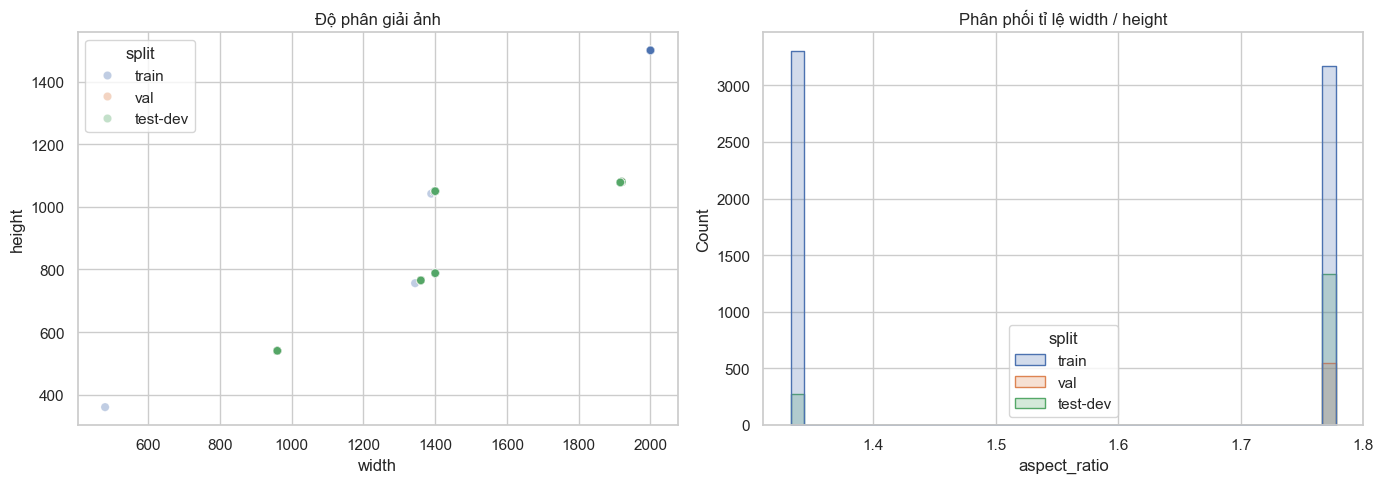

In [7]:
image_stats = images_df.assign(aspect_ratio=images_df.width / images_df.height)
display(image_stats.groupby('split')[['width', 'height', 'aspect_ratio', 'file_size_kb']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=image_stats, x='width', y='height', hue='split', alpha=.35, ax=axes[0])
axes[0].set_title('Độ phân giải ảnh')
sns.histplot(data=image_stats, x='aspect_ratio', hue='split', bins=40, element='step', ax=axes[1])
axes[1].set_title('Phân phối tỉ lệ width / height')
plt.tight_layout();

## 4. Phân phối lớp và mức mất cân bằng

Chỉ phân tích các box có `status == 'keep'`, tức chính xác các box sẽ được ghi sang YOLO.

,category,class_name,objects,percent
3,4,car,187004,40.91
0,1,pedestrian,109187,23.89
9,10,motor,40378,8.83
1,2,people,38560,8.44
4,5,van,32702,7.15
5,6,truck,16284,3.56
2,3,bicycle,13069,2.86
8,9,bus,9117,1.99
6,7,tricycle,6387,1.40
7,8,awning-tricycle,4377,0.96


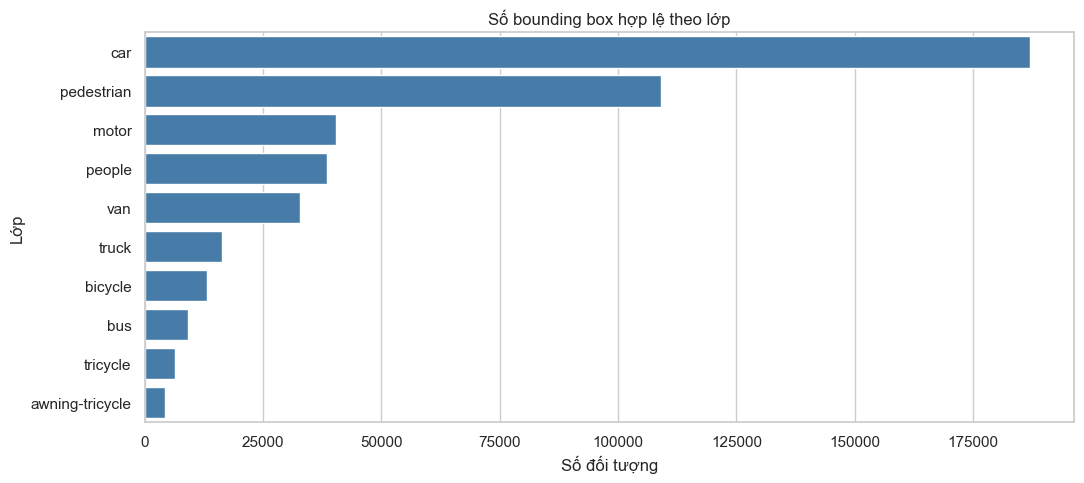

In [8]:
valid_boxes = boxes_df.query("status == 'keep'").copy()
class_counts = (valid_boxes.groupby(['category', 'class_name']).size()
                .rename('objects').reset_index().sort_values('objects', ascending=False))
class_counts['percent'] = 100 * class_counts.objects / class_counts.objects.sum()
display(class_counts.round({'percent': 2}))

plt.figure(figsize=(11, 5))
sns.barplot(data=class_counts, x='objects', y='class_name', color='#377eb8')
plt.title('Số bounding box hợp lệ theo lớp')
plt.xlabel('Số đối tượng'); plt.ylabel('Lớp'); plt.tight_layout();

## 5. Hình học bounding box và vật thể nhỏ

`relative_area` là diện tích box / diện tích ảnh. Các ngưỡng dưới đây chỉ dùng để EDA; pipeline mặc định không xóa vật thể nhỏ hợp lệ vì đó là tín hiệu quan trọng của VisDrone.

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
clipped_width,457065.0,36.6511,38.9668,2.0000,3.0000,5.0000,12.0000,24.0000,46.0000,110.0000,189.0000,983.0000
clipped_height,457065.0,36.0649,32.7265,1.0000,5.0000,8.0000,16.0000,26.0000,44.0000,97.0000,166.0000,790.0000
area_px,457065.0,2243.8620,6189.2745,3.0000,21.0000,50.0000,221.0000,627.0000,1850.0000,9102.0000,25812.1200,355432.0000
relative_area,457065.0,0.0015,0.0039,0.0000,0.0000,0.0000,0.0002,0.0005,0.0013,0.0061,0.0163,0.3416
aspect_ratio,457065.0,1.0737,0.6651,0.0536,0.2778,0.3529,0.5500,0.8855,1.4286,2.3889,2.9545,12.5417


,value
box < 16x16 px (%),38.91
box < 32x32 px (%),72.13
area < 0.1% ảnh (%),69.19
box bị clip (%),0.00


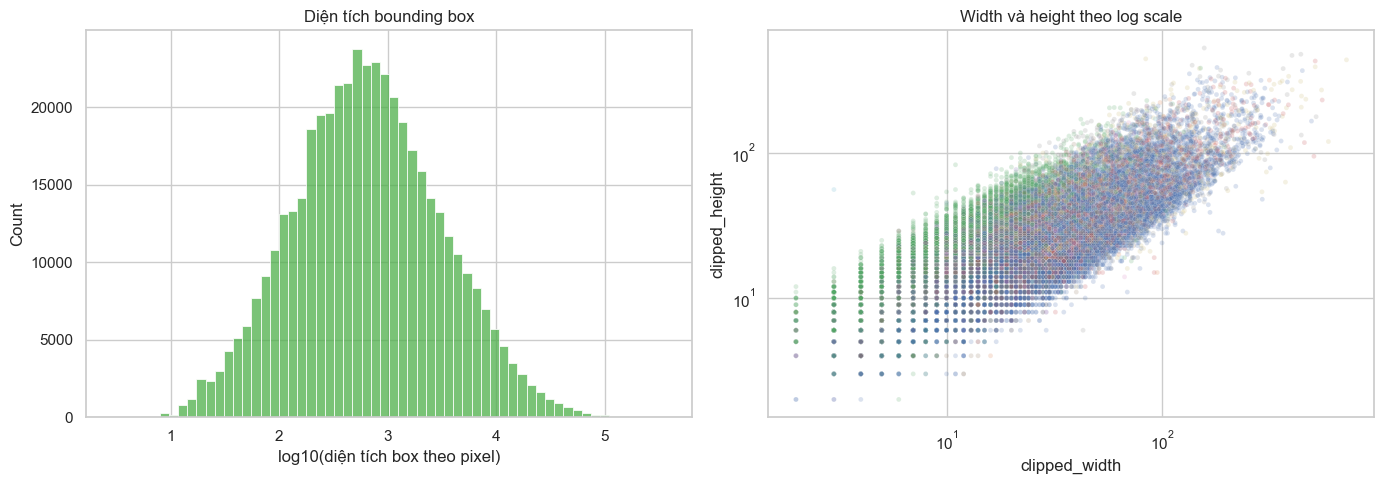

In [9]:
geometry_summary = valid_boxes[['clipped_width', 'clipped_height', 'area_px', 'relative_area', 'aspect_ratio']].describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99]
).T
display(geometry_summary.round(4))

small_object_summary = pd.Series({
    'box < 16x16 px (%)': 100 * ((valid_boxes.clipped_width < 16) | (valid_boxes.clipped_height < 16)).mean(),
    'box < 32x32 px (%)': 100 * ((valid_boxes.clipped_width < 32) | (valid_boxes.clipped_height < 32)).mean(),
    'area < 0.1% ảnh (%)': 100 * (valid_boxes.relative_area < .001).mean(),
    'box bị clip (%)': 100 * valid_boxes.was_clipped.mean(),
}).round(2)
display(small_object_summary.to_frame('value'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(np.log10(valid_boxes.area_px.clip(lower=1)), bins=60, ax=axes[0], color='#4daf4a')
axes[0].set(xlabel='log10(diện tích box theo pixel)', title='Diện tích bounding box')
sample = valid_boxes.sample(min(30000, len(valid_boxes)), random_state=RANDOM_SEED)
sns.scatterplot(data=sample, x='clipped_width', y='clipped_height', hue='class_name', alpha=.2, s=12, legend=False, ax=axes[1])
axes[1].set(xscale='log', yscale='log', title='Width và height theo log scale')
plt.tight_layout();

## 6. Mật độ, truncation và occlusion

Ảnh có rất nhiều đối tượng và nhiều box bị che khuất. Không nên loại các box occlusion/truncation cao một cách mặc định; có thể dùng chúng để phân tích lỗi sau huấn luyện.

raw_objects                                               \
               count   mean    std  min   25%   50%    75%    max   
split                                                               
test-dev      1610.0  48.17  46.86  1.0  21.0  37.0  58.00  498.0   
train         6471.0  54.64  45.22  1.0  24.0  43.0  72.00  914.0   
val            548.0  73.30  47.62  1.0  42.0  68.0  96.25  341.0   

         trainable_objects                                               
                     count   mean    std  min    25%   50%   75%    max  
split                                                                    
test-dev            1610.0  46.65  44.06  1.0  20.00  36.0  57.0  461.0  
train               6471.0  53.04  43.84  1.0  24.00  42.0  70.0  902.0  
val                  548.0  70.73  46.00  1.0  39.75  65.0  93.0  317.0

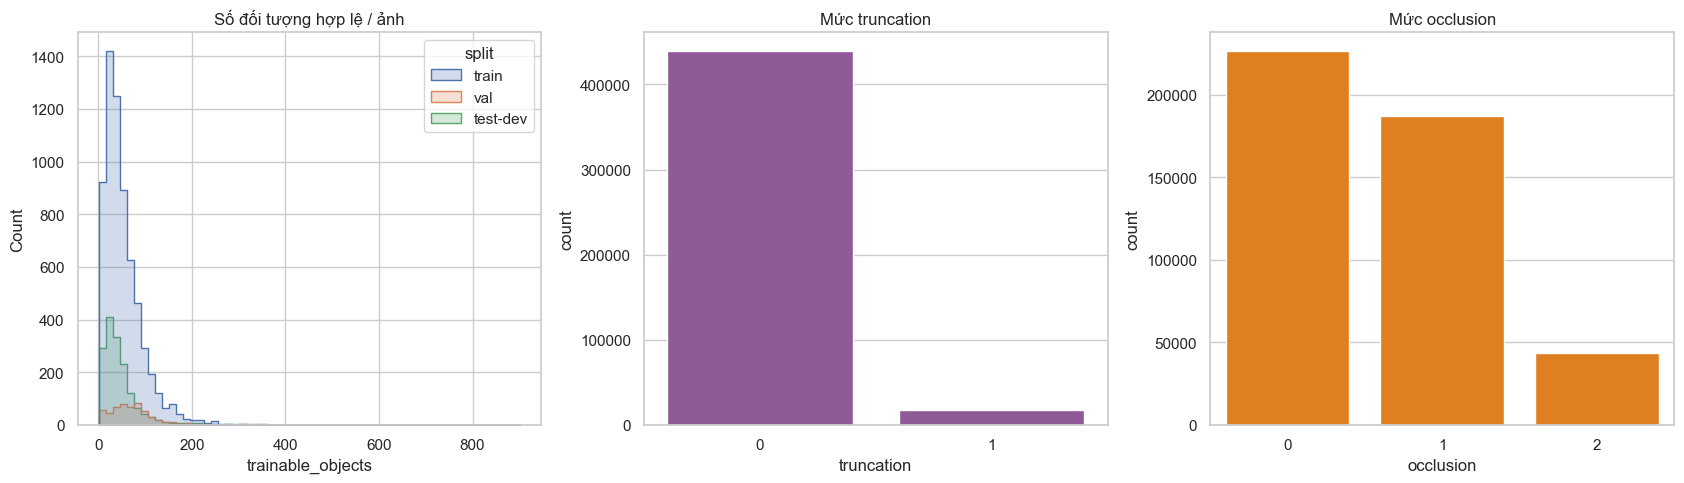

In [10]:
display(images_df.groupby('split')[['raw_objects', 'trainable_objects']].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sns.histplot(data=images_df, x='trainable_objects', hue='split', bins=60, element='step', ax=axes[0])
axes[0].set_title('Số đối tượng hợp lệ / ảnh')
sns.countplot(data=valid_boxes, x='truncation', color='#984ea3', ax=axes[1])
axes[1].set_title('Mức truncation')
sns.countplot(data=valid_boxes, x='occlusion', color='#ff7f00', ax=axes[2])
axes[2].set_title('Mức occlusion')
plt.tight_layout();

## 7. Trực quan hóa ảnh và nhãn gốc

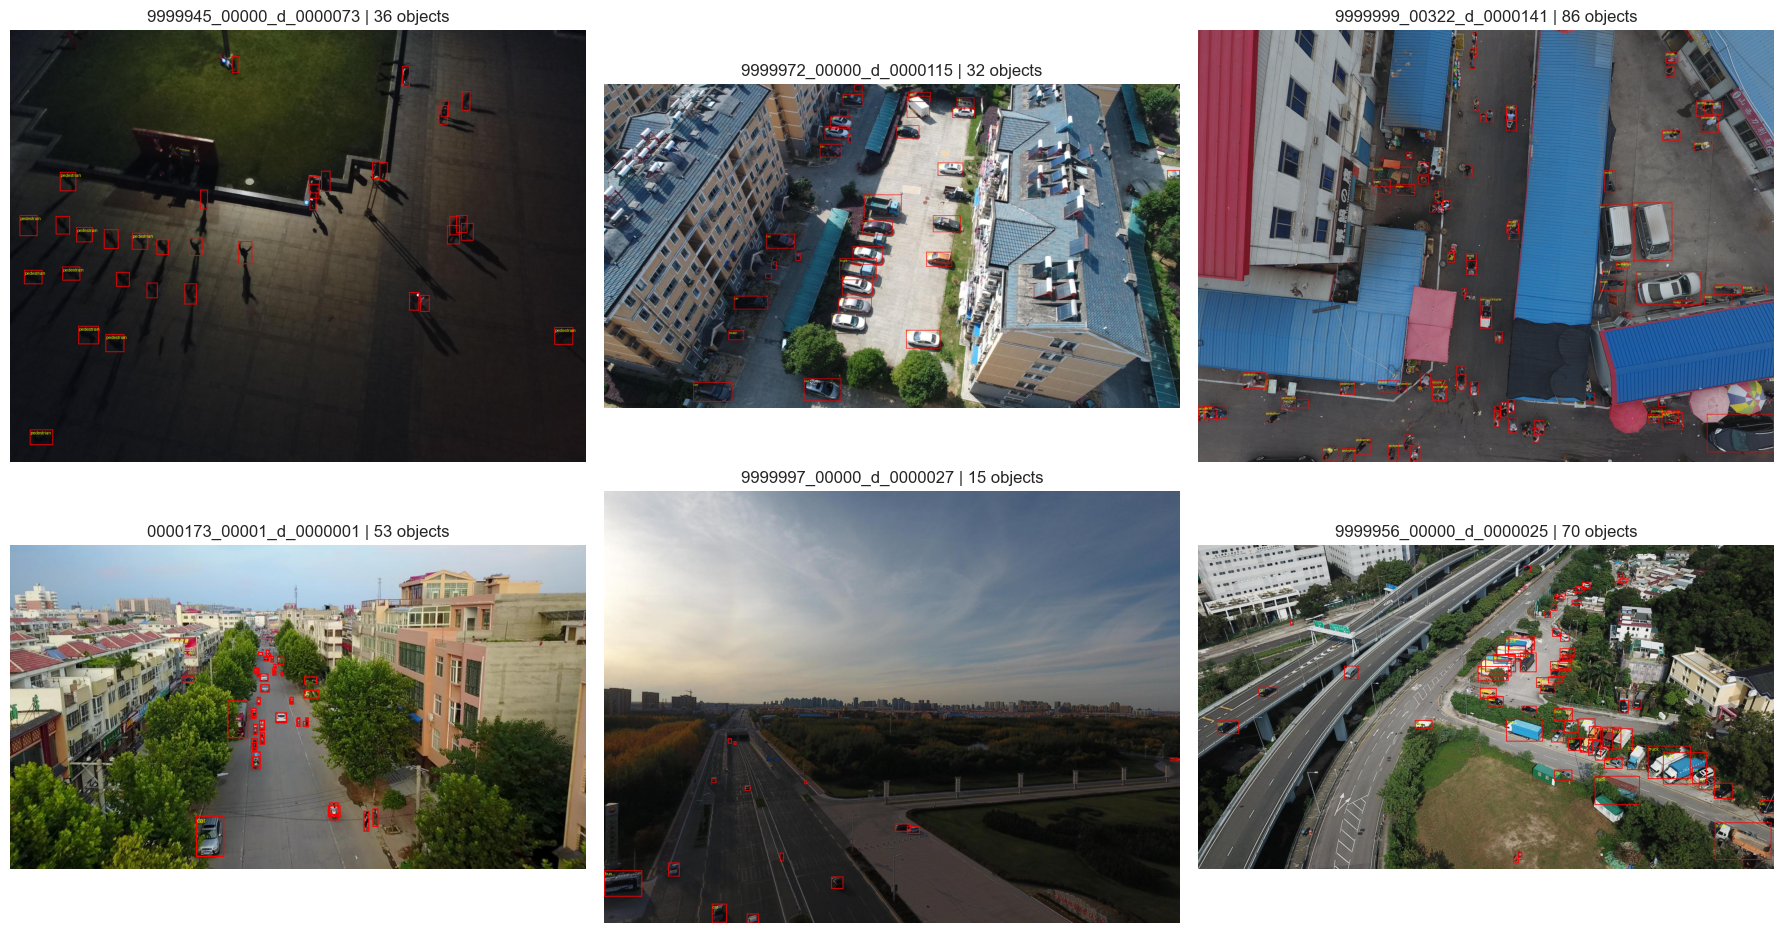

In [11]:
def draw_visdrone_sample(row, line_width=2):
    image = Image.open(row.image_path).convert('RGB')
    draw = ImageDraw.Draw(image)
    annotation_path = Path(row.annotation_path)
    annotations, _ = read_annotation_file(annotation_path)
    for ann in annotations:
        if ann.score <= 0 or ann.category not in CLASS_NAMES:
            continue
        x1, y1 = max(0, ann.x), max(0, ann.y)
        x2, y2 = min(image.width, ann.x + ann.width), min(image.height, ann.y + ann.height)
        if x2 <= x1 or y2 <= y1:
            continue
        draw.rectangle((x1, y1, x2, y2), outline='red', width=line_width)
        if ann.width > 35 and ann.height > 20:
            draw.text((x1 + 2, y1 + 2), CLASS_NAMES[ann.category], fill='yellow')
    return image

sample_rows = images_df.query("split == 'train' and trainable_objects > 0").sample(6, random_state=RANDOM_SEED)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (_, row) in zip(axes.flat, sample_rows.iterrows()):
    ax.imshow(draw_visdrone_sample(row))
    ax.set_title(f'{row.image_id} | {row.trainable_objects} objects')
    ax.axis('off')
plt.tight_layout();

## 8. Kết luận preprocessing

Pipeline trong `src/visdrone_data.py` và CLI `src/preprocess_visdrone.py` thực hiện:

1. Tự tìm các split dù thư mục bị lồng trùng tên.
2. Ghép ảnh và annotation theo stem, báo file thiếu/hỏng/dòng malformed.
3. Bỏ `score <= 0`, category `0`/`11`; ánh xạ category `1..10` thành class chung `0..9`.
4. Loại box width/height không dương hoặc nằm hoàn toàn ngoài ảnh; clip box vượt biên.
5. Lưu box sạch dạng trung gian `xywh` tuyệt đối trong JSONL, chưa phụ thuộc YOLO hay DETR.
6. Giữ nguyên ảnh gốc; mặc định tạo hardlink để không nhân đôi dung lượng (fallback sang copy).
7. Sinh `dataset_manifest.json`, JSONL theo split và `preprocessing_report.json`; converter riêng sẽ sinh YOLO hoặc COCO/DETR.

**Khuyến nghị train:** bắt đầu với `imgsz=960` hoặc `1280`, bật augmentation hình học/màu ở mức vừa, giữ mosaic ở giai đoạn đầu, và theo dõi AP theo từng lớp vì phân phối lớp mất cân bằng. Không dùng horizontal flip nếu quy trình nghiệp vụ coi hướng chuyển động là đặc trưng; với detection thông thường có thể dùng. Không crop ngẫu nhiên quá mạnh vì dễ cắt mất các vật thể nhỏ.

In [12]:
print('Lệnh kiểm tra không ghi file:')
print('python src/preprocess_visdrone.py --data-root data --dry-run')
print('\nLệnh tạo dữ liệu trung gian:')
print('python src/preprocess_visdrone.py --data-root data --output-root data/processed/VisDrone')
print('\nChọn một định dạng đầu ra:')
print('python src/convert_visdrone_to_yolo.py')
print('python src/convert_visdrone_to_detr.py')
print('\nTrain YOLO sau khi convert:')
print('yolo detect train data=data/formatted/yolo/VisDrone/visdrone_yolo.yaml model=yolo11n.pt imgsz=960')

Lệnh kiểm tra không ghi file:
python src/preprocess_visdrone.py --data-root data --dry-run

Lệnh tạo dữ liệu trung gian:
python src/preprocess_visdrone.py --data-root data --output-root data/processed/VisDrone

Chọn một định dạng đầu ra:
python src/convert_visdrone_to_yolo.py
python src/convert_visdrone_to_detr.py

Train YOLO sau khi convert:
yolo detect train data=data/formatted/yolo/VisDrone/visdrone_yolo.yaml model=yolo11n.pt imgsz=960
